The point of this notebook is to generate the spectral plots that we need for the supplemental methods section on the telluric corrections for our Li-WD paper. Basically these should show that the corrections didn't create the potassium signal and that they worked.

To that end, I think I might need 2 plots for this:

- J1644 before and after telluric corrections

- Comp star stacked on a plot with prior to telluric correction, telluric correction, and template spectrum

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
print(os.getcwd())

all_avg
/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'



## J1644 Before and After Telluric correction

In [3]:

target_nocorr_file='ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits'
target_tellcorr_file='ravg_fwctb.GaiaJ1644m0449_20190825_tellcorr_400m2.fits'
model_spec_file='J1644_fit_flambda.dms'
target_nocorr_file=target_dir+target_nocorr_file
target_tellcorr_file=target_dir+target_tellcorr_file
model_spec_file= target_dir+model_spec_file
print(model_spec_file)

/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/J1644_fit_flambda.dms


## Comp star stacked spectra

In [4]:
comp_tellcorr_file= "ravg_fwctb.GaiaJ1644m0449other_20190825_tellcorr_400m2.fits"
comp_nocorr_file="ravg_fwctb.GaiaJ1644m0449other_20190825_400m2.fits"
sdss_path = '/Users/BenKaiser/Desktop/SDSS_speclib/'
#sdss_name='M0_-0.5_Dwarf.fits'
sdss_name='K7_+0.0_Dwarf.fits'
sdss_label='K7 Template'
sdss_name=sdss_path+sdss_name
comp_tellcorr_file=target_dir+comp_tellcorr_file
comp_nocorr_file=target_dir+comp_nocorr_file

#### Retrieving the SDSS template spectrum

In [5]:
sdss_spec, sdss_header, sdss_noise= spt.retrieve_sdss_spec(sdss_name)

wavelengths.min:  3650.05
new_wavelengths.min(): 3649.00964964


#### retrieving the comp star spectra

In [6]:
print(comp_tellcorr_file)
print(comp_nocorr_file)
comp_tellcorr_spec, comp_tellcorr_header, anoise= spt.retrieve_spec(comp_tellcorr_file)
comp_nocorr_spec, comp_nocorr_header, bnoise= spt.retrieve_spec(comp_nocorr_file)

/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/ravg_fwctb.GaiaJ1644m0449other_20190825_tellcorr_400m2.fits
/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/ravg_fwctb.GaiaJ1644m0449other_20190825_400m2.fits


I do not need to clean the SDSS spectrum because I'm going to be limiting the plot window anyway, so fuck it.



wavelength-based norm range selected [7470, 7530]



Telluric Correction smoothed normed[7470, 7530]


wavelength-based norm range selected [7470, 7530]



No Correction smoothed normed[7470, 7530]
sdss_see_sig 0.990799716914
see_sig 1.87898168821
conv_see_sig 1.59652375666


wavelength-based norm range selected [7470, 7530]



K7 Template smoothed normed[7470, 7530]


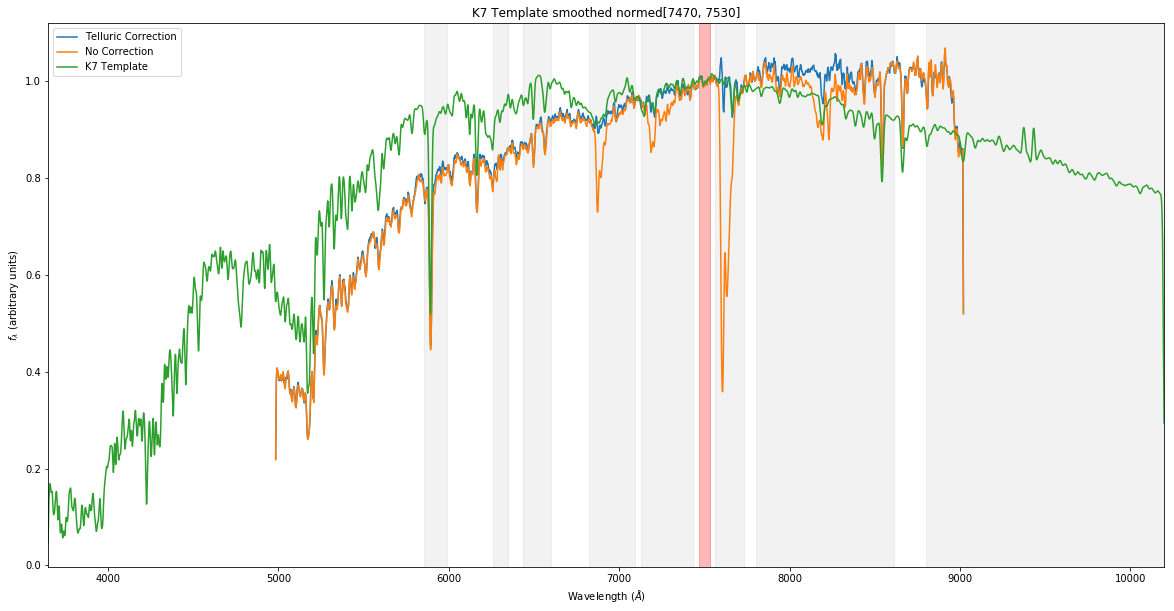

In [7]:
plt.figure(figsize=(20,10))
norm_range=[7470, 7530]
obs_pix_width=5
kernel='box'
ps.plot_spectrum(comp_tellcorr_spec,"Telluric Correction",comp_tellcorr_header, norm=True, norm_range=norm_range, smooth=True, pix_width=obs_pix_width, kernel_type=kernel)
ps.plot_spectrum(comp_nocorr_spec,"No Correction",comp_nocorr_header, norm=True, norm_range=norm_range, smooth=True, pix_width=obs_pix_width, kernel_type=kernel)
ps.plot_spectrum(sdss_spec,sdss_label,comp_tellcorr_header, norm=True, norm_range=norm_range, smooth=True, kernel_type='sdss_match', pix_width=obs_pix_width )
spt.show_plot()


So that was a good demonstrational version of the plot, but 

In [8]:
norm_range=[6000,6100]
#norm_range=[7470, 7530]
obs_pix_width=5
kernel='box'

In [9]:
sm_comp_tellcorr_spec= ps.convolve_spectrum(comp_tellcorr_spec, comp_tellcorr_header, kernel_type=kernel, pix_width=obs_pix_width)
sm_comp_nocorr_spec= ps.convolve_spectrum(comp_nocorr_spec, comp_nocorr_header, kernel_type=kernel, pix_width=obs_pix_width)
sm_sdss_spec= ps.convolve_spectrum(sdss_spec, comp_tellcorr_header, kernel_type='sdss_match',pix_width=1)

sm_comp_tellcorr_spec= ps.norm_spectrum(sm_comp_tellcorr_spec, norm_range, show_norm_range=False)
sm_comp_nocorr_spec= ps.norm_spectrum(sm_comp_nocorr_spec, norm_range, show_norm_range=False)
sm_sdss_spec= ps.norm_spectrum(sm_sdss_spec, norm_range, show_norm_range=False)

sdss_see_sig 0.990799716914
see_sig 1.87898168821
conv_see_sig 1.59652375666


wavelength-based norm range selected [6000, 6100]





wavelength-based norm range selected [6000, 6100]





wavelength-based norm range selected [6000, 6100]





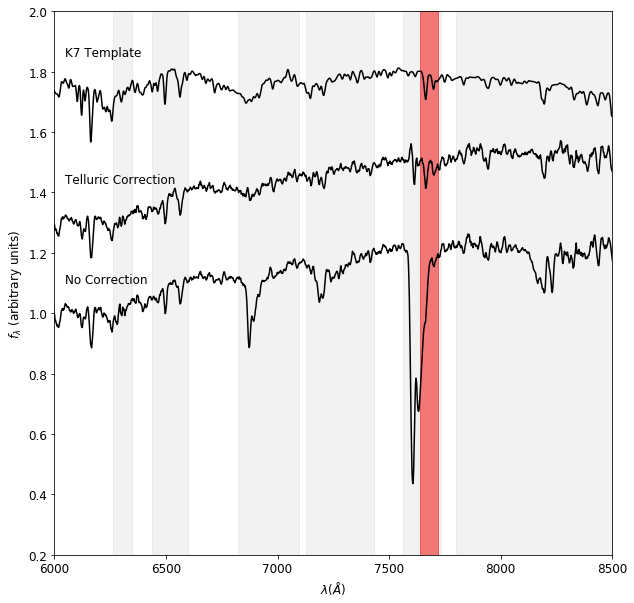

In [10]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,10))
highlight_range=[7640,7720]
label_pos=3.3
label_off=65
x_pos= 6050
y_pos= 1.1
v_offset=0.3

plt.axvspan(highlight_range[0], highlight_range[1], alpha=0.5, color='r')


plt.plot(sm_comp_nocorr_spec[0],sm_comp_nocorr_spec[1],  color='k')
plt.plot(sm_comp_tellcorr_spec[0],sm_comp_tellcorr_spec[1]+v_offset, color='k')
plt.plot(sm_sdss_spec[0],sm_sdss_spec[1]+2.5*v_offset, color='k')

plt.text(x_pos, y_pos, 'No Correction', color='k')
plt.text(x_pos, y_pos+1.1*v_offset, 'Telluric Correction', color='k')
plt.text(x_pos, y_pos+2.5*v_offset, sdss_label, color='k')






#plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax([sm_M0703_spec[0], sm_M0825_spec[0]]))
plt.xlim(6000, 8500)
plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')
plt.ylim(0.2,2)
spt.show_plot(line_id='', show_legend=False)

## Now doing that again with the target spectrum for demonstration purposes... Not sure if this one will go in the paper or not... but it'll be here.

In [11]:
print(target_tellcorr_file)
print(target_nocorr_file)
targ_tellcorr_spec, targ_tellcorr_header, anoise= spt.retrieve_spec(target_tellcorr_file)
targ_nocorr_spec, targ_nocorr_header, bnoise= spt.retrieve_spec(target_nocorr_file)

/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/ravg_fwctb.GaiaJ1644m0449_20190825_tellcorr_400m2.fits
/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits


In [12]:
sm_targ_tellcorr_spec= ps.convolve_spectrum(targ_tellcorr_spec, targ_tellcorr_header, kernel_type=kernel, pix_width=obs_pix_width)
sm_targ_nocorr_spec= ps.convolve_spectrum(targ_nocorr_spec, targ_nocorr_header, kernel_type=kernel, pix_width=obs_pix_width)

#sm_targ_tellcorr_spec= ps.norm_spectrum(sm_targ_tellcorr_spec, norm_range, show_norm_range=False)
#sm_targ_nocorr_spec= ps.norm_spectrum(sm_targ_nocorr_spec, norm_range, show_norm_range=False)


/Users/BenKaiser/.virtualenvs/stars/lib/python2.7/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


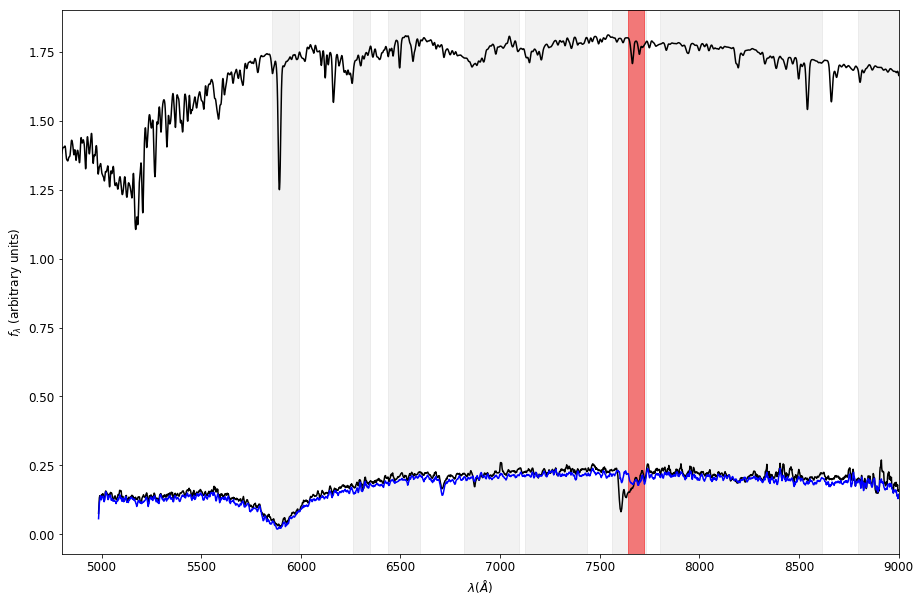

In [13]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(15,10))
#highlight_range=[7640,7720]
label_pos=3.3
label_off=65
x_pos= 6050
y_pos= 1.1
v_offset=0.3

plt.axvspan(highlight_range[0], highlight_range[1], alpha=0.5, color='r')


plt.plot(sm_targ_nocorr_spec[0],sm_targ_nocorr_spec[1],  color='k')
plt.plot(sm_targ_tellcorr_spec[0],sm_targ_tellcorr_spec[1]+0*v_offset, color='b')

plt.plot(sm_sdss_spec[0],sm_sdss_spec[1]+2.5*v_offset, color='k')

#plt.text(x_pos, y_pos, 'No Correction', color='k')
#plt.text(x_pos, y_pos+1.1*v_offset, 'Telluric Correction', color='k')
#plt.text(x_pos, y_pos+2.5*v_offset, sdss_label, color='k')






#plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax([sm_M0703_spec[0], sm_M0825_spec[0]]))
#plt.xlim(6000, 8500)
plt.xlim(4800,9000)
plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')
#plt.ylim(0.2,2)
spt.show_plot(line_id='', show_legend=True)

Ok. Well that is mildly concerning I would say...

/Users/BenKaiser/Desktop/Goodman_ref_files/line_lists/alkali_lines_vac.csv


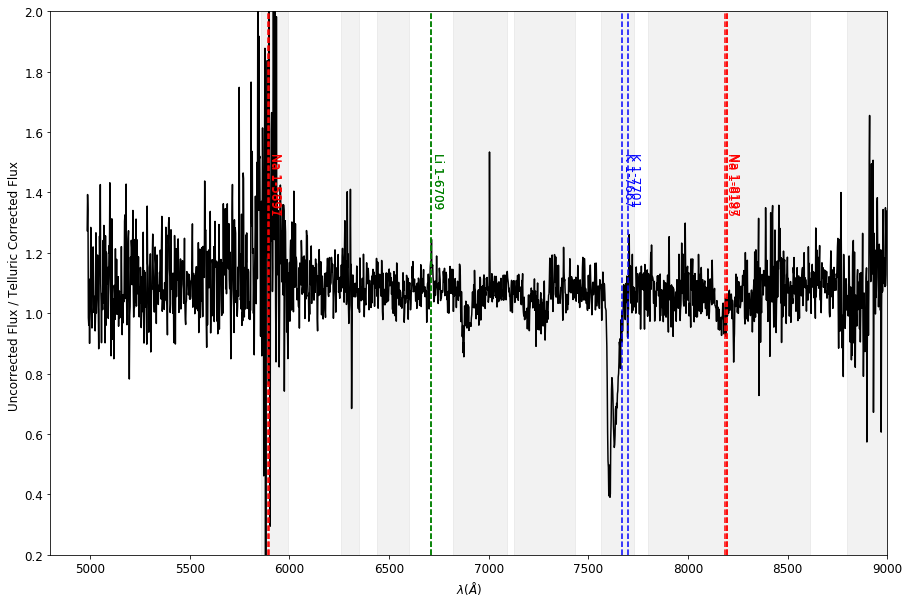

In [14]:
fig= plt.figure(figsize=(15,10))
plt.plot(targ_nocorr_spec[0],targ_nocorr_spec[1]/targ_tellcorr_spec[1],  color='k')
#plt.plot(targ_tellcorr_spec[0],targ_tellcorr_spec[1], color='b')
plt.xlim(4800,9000)
plt.ylabel(r'Uncorrected Flux / Telluric Corrected Flux ')
plt.xlabel(r'$\lambda(\AA)$')
plt.ylim(0.2,2)
spt.show_plot(line_id='alkali', show_legend=True)

So looking at my creation dates for the files in the target directory, it would seem that the uncorrected spectra were generated on September 12, 2019. The corrected spectra were generated on February 11, 2020. That's A LOT of time between those two... I also now recall that I usually perform the telluric correction in the midst of the correction for the overall flux calibration, so inevitably when that first part doesn't match there are problems. I should check the headers to make sure the methods match up. I don't think I even had Gaussian fitting to the trace running when I did the September run. Less sure with February.

So it would seem they were actually just different extractions from the get-go... so that's not good. One's background shift is 32, while the other's is 50. That's a pretty substantial piece of information and probably means I need to redo the re-extraction using the same wavelength calibrated versions... Fucking hell...

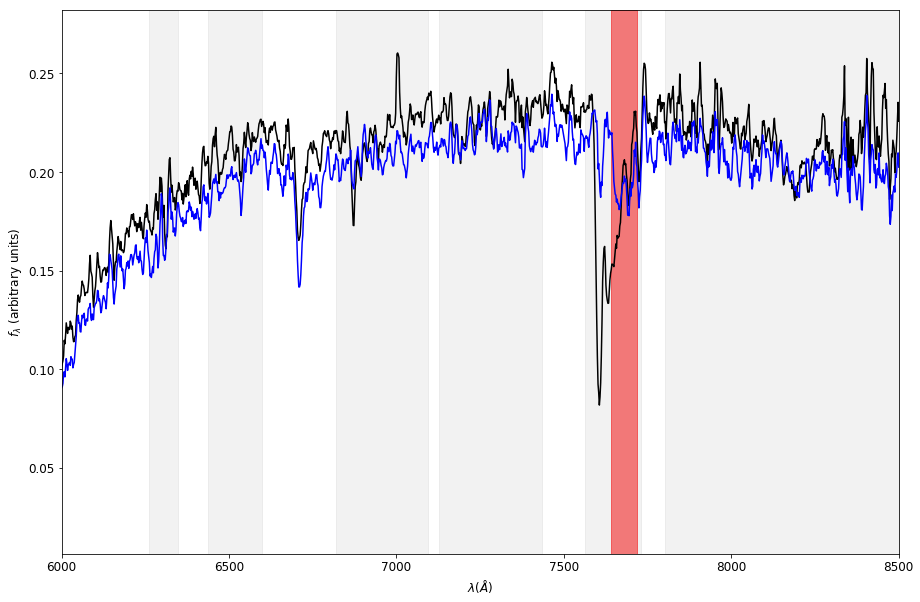

In [15]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(15,10))
#highlight_range=[7640,7720]
label_pos=3.3
label_off=65
x_pos= 6050
y_pos= 1.1
v_offset=0.3

plt.axvspan(highlight_range[0], highlight_range[1], alpha=0.5, color='r')


plt.plot(sm_targ_nocorr_spec[0],sm_targ_nocorr_spec[1],  color='k')
plt.plot(sm_targ_tellcorr_spec[0],sm_targ_tellcorr_spec[1]+0*v_offset, color='b')

#plt.plot(sm_sdss_spec[0],sm_sdss_spec[1]+2.5*v_offset, color='k')

#plt.text(x_pos, y_pos, 'No Correction', color='k')
#plt.text(x_pos, y_pos+1.1*v_offset, 'Telluric Correction', color='k')
#plt.text(x_pos, y_pos+2.5*v_offset, sdss_label, color='k')






#plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax([sm_M0703_spec[0], sm_M0825_spec[0]]))
plt.xlim(6000, 8500)
plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')
#plt.ylim(0.2,2)
spt.show_plot(line_id='', show_legend=True)

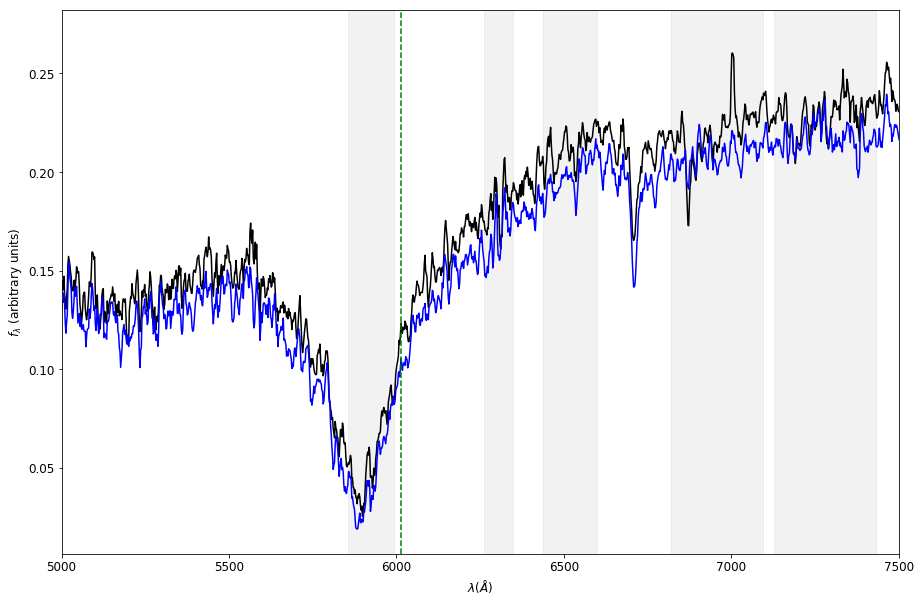

In [16]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(15,10))
#highlight_range=[7640,7720]
label_pos=3.3
label_off=65
x_pos= 6050
y_pos= 1.1
v_offset=0.3

plt.axvspan(highlight_range[0], highlight_range[1], alpha=0.5, color='r')


plt.plot(sm_targ_nocorr_spec[0],sm_targ_nocorr_spec[1],  color='k')
plt.plot(sm_targ_tellcorr_spec[0],sm_targ_tellcorr_spec[1]+0*v_offset, color='b')

#plt.plot(sm_sdss_spec[0],sm_sdss_spec[1]+2.5*v_offset, color='k')

#plt.text(x_pos, y_pos, 'No Correction', color='k')
#plt.text(x_pos, y_pos+1.1*v_offset, 'Telluric Correction', color='k')
#plt.text(x_pos, y_pos+2.5*v_offset, sdss_label, color='k')






#plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax([sm_M0703_spec[0], sm_M0825_spec[0]]))
plt.xlim(5000, 7500)
plt.axvline(x=6014, linestyle='--', color='g')
plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')
#plt.ylim(0.2,2)
spt.show_plot(line_id='', show_legend=True)

## J2356 plot to present the data that we keep saying we have.

In [17]:
#target_nocorr_file='ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits'
target_tellcorr_file='ravg_fwctb.WD2356m209_20190601_ted_tellcorr_400m2.fits'
#model_spec_file='J1644_fit_flambda.dms'
#target_nocorr_file=target_dir+target_nocorr_file
target_tellcorr_file=target_dir+target_tellcorr_file
#model_spec_file= target_dir+model_spec_file
#print(model_spec_file)

In [18]:
print(target_tellcorr_file)
#print(target_nocorr_file)
targ_tellcorr_spec, targ_tellcorr_header, anoise= spt.retrieve_spec(target_tellcorr_file)
#targ_nocorr_spec, targ_nocorr_header, bnoise= spt.retrieve_spec(target_nocorr_file)

/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/ravg_fwctb.WD2356m209_20190601_ted_tellcorr_400m2.fits


In [19]:
sm_targ_tellcorr_spec= ps.convolve_spectrum(targ_tellcorr_spec, targ_tellcorr_header, kernel_type=kernel, pix_width=obs_pix_width)
#sm_targ_nocorr_spec= ps.convolve_spectrum(targ_nocorr_spec, targ_nocorr_header, kernel_type=kernel, pix_width=obs_pix_width)

#sm_targ_tellcorr_spec= ps.norm_spectrum(sm_targ_tellcorr_spec, norm_range, show_norm_range=False)
#sm_targ_nocorr_spec= ps.norm_spectrum(sm_targ_nocorr_spec, norm_range, show_norm_range=False)



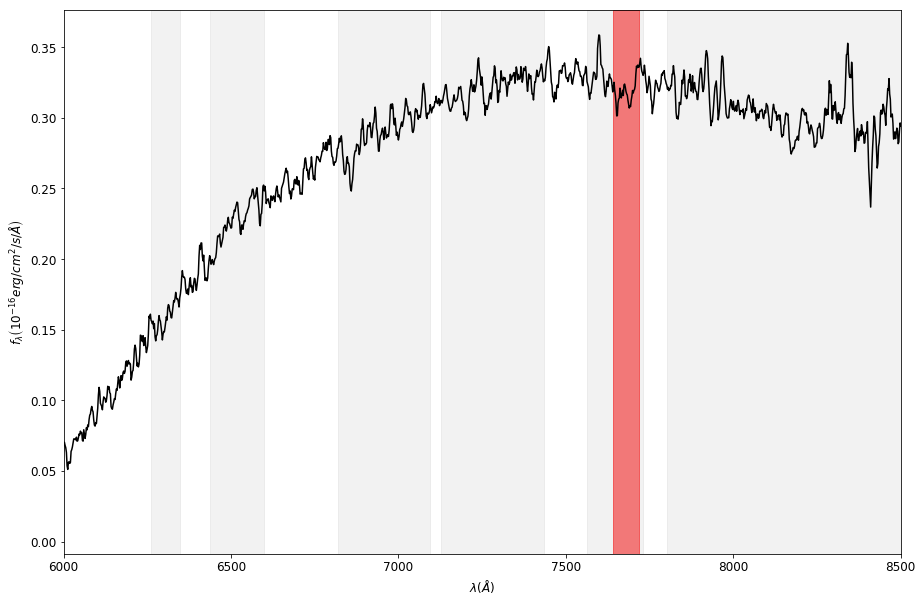

In [20]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(15,10))
#highlight_range=[7640,7720]
label_pos=3.3
label_off=65
x_pos= 6050
y_pos= 1.1
v_offset=0.3

plt.axvspan(highlight_range[0], highlight_range[1], alpha=0.5, color='r')


#plt.plot(sm_targ_nocorr_spec[0],sm_targ_nocorr_spec[1],  color='k')
plt.plot(sm_targ_tellcorr_spec[0],sm_targ_tellcorr_spec[1], color='k')

#plt.plot(sm_sdss_spec[0],sm_sdss_spec[1]+2.5*v_offset, color='k')

#plt.text(x_pos, y_pos, 'No Correction', color='k')
#plt.text(x_pos, y_pos+1.1*v_offset, 'Telluric Correction', color='k')
#plt.text(x_pos, y_pos+2.5*v_offset, sdss_label, color='k')






#plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax([sm_M0703_spec[0], sm_M0825_spec[0]]))
plt.xlim(6000, 8500)
plt.ylabel(r'$f_{\lambda} \left(10^{-16} erg/cm^2/s/\AA\right)$')
plt.xlabel(r'$\lambda(\AA)$')
#plt.ylim(0.2,2)
spt.show_plot(line_id='', show_legend=False)